In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from langdetect import detect
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay


In [ ]:
df = pd.read_json("YOUR CODE.json")

df.shape


(10588, 13)

In [3]:
df.columns.tolist()


['date',
 'userName',
 'title',
 'rating',
 'isEdited',
 'review',
 'crawled_at',
 'url',
 'app_id',
 'country',
 'app_name',
 '_id',
 'developerResponse']

In [ ]:
reviews = df[
    ["review", "rating", "app_name", "date", "country"]].copy()

reviews = reviews.dropna(subset=["review", "rating"])
reviews = reviews.rename(columns={"review": "text"})
reviews["text"] = reviews["text"].astype(str).str.strip()

reviews.head()


,text,rating,app_name,date,country
0,"Sehr gute App, erfüllt Ihren Zweck. Finde so g...",5,whatsapp-messenger,2017-09-08 11:58:17,at
1,Bester Messenger Dienst,5,whatsapp-messenger,2017-09-06 15:32:26,at
2,"Wegen den neuen Richtlinien, werd ich WhatsApp...",1,whatsapp-messenger,2021-01-08 22:31:30,at
3,Furchtbare datenschutzpolitik,1,whatsapp-messenger,2019-01-15 12:18:55,at
4,Wäre org wenn’s eine Abstimmungs-Funktion für ...,4,whatsapp-messenger,2020-05-24 13:51:44,at


In [5]:
def get_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

reviews["language"] = reviews["text"].apply(get_language)

reviews["language"].value_counts().head(10)


language
de         6801
en         2093
unknown     271
af          237
id          129
no          117
fr          100
nl           97
it           83
sv           74
Name: count, dtype: int64

In [6]:
english_reviews = reviews[
    reviews["language"] == "en"].copy()

print("All reviews:", len(reviews))
print("English reviews:", len(english_reviews))


All reviews: 10588
English reviews: 2093


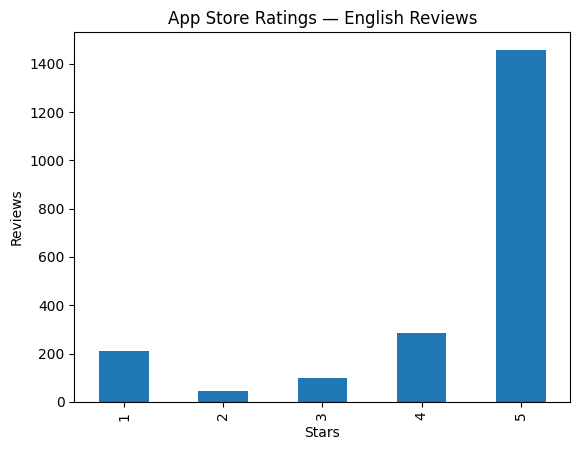

In [7]:
english_reviews["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("App Store Ratings — English Reviews")
plt.xlabel("Stars")
plt.ylabel("Reviews")
plt.show()


In [8]:
def sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    return "positive"

english_reviews["sentiment"] = english_reviews["rating"].apply(sentiment)

english_reviews["sentiment"].value_counts()


sentiment
positive    1740
negative     256
neutral       97
Name: count, dtype: int64

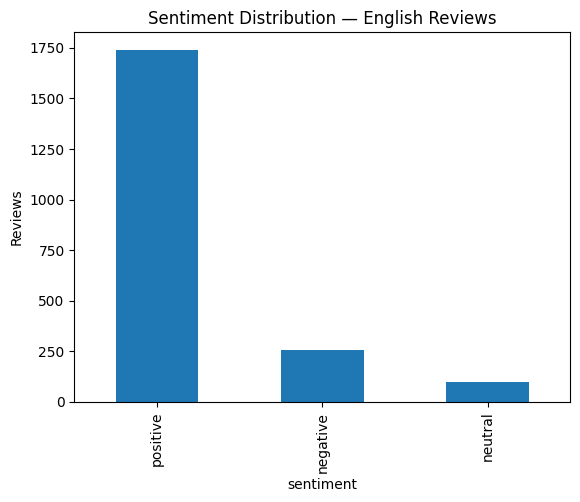

In [9]:
english_reviews["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution — English Reviews")
plt.ylabel("Reviews")
plt.show()


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    english_reviews["text"],
    english_reviews["sentiment"],
    test_size=0.2,
    stratify=english_reviews["sentiment"],
    random_state=42)


In [11]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english")

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [12]:
logistic = LogisticRegression(
    max_iter=500,
    class_weight="balanced"
)

logistic.fit(X_train_tfidf, y_train)
logistic_pred = logistic.predict(X_test_tfidf)

print(classification_report(y_test, logistic_pred))


              precision    recall  f1-score   support

    negative       0.49      0.63      0.55        51
     neutral       0.15      0.20      0.17        20
    positive       0.91      0.86      0.89       348

    accuracy                           0.80       419
   macro avg       0.52      0.56      0.54       419
weighted avg       0.83      0.80      0.81       419



In [13]:
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

print(classification_report(y_test, nb_pred))


              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        51
     neutral       0.00      0.00      0.00        20
    positive       0.83      1.00      0.91       348

    accuracy                           0.83       419
   macro avg       0.28      0.33      0.30       419
weighted avg       0.69      0.83      0.75       419



/Users/mshvrnina/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mshvrnina/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/mshvrnina/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [14]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, nb_pred)
    ],
    "Macro F1": [
        f1_score(y_test, logistic_pred, average="macro"),
        f1_score(y_test, nb_pred, average="macro")
    ]
})

results


,Model,Accuracy,Macro F1
0,Logistic Regression,0.799523,0.535954
1,Naive Bayes,0.830549,0.302477


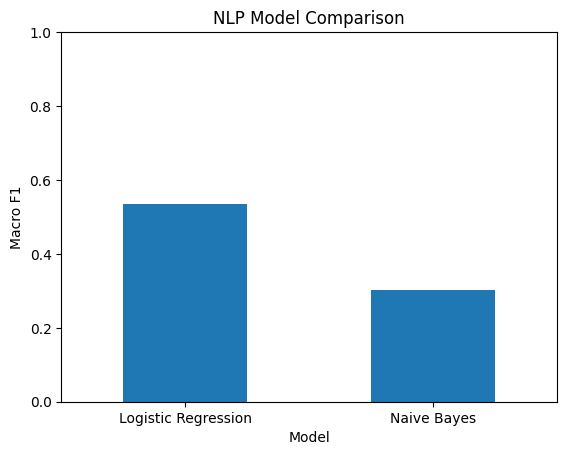

In [ ]:
results.plot(
    x="Model",
    y="Macro F1",
    kind="bar",
    legend=False)

plt.title("NLP Model Comparison")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()


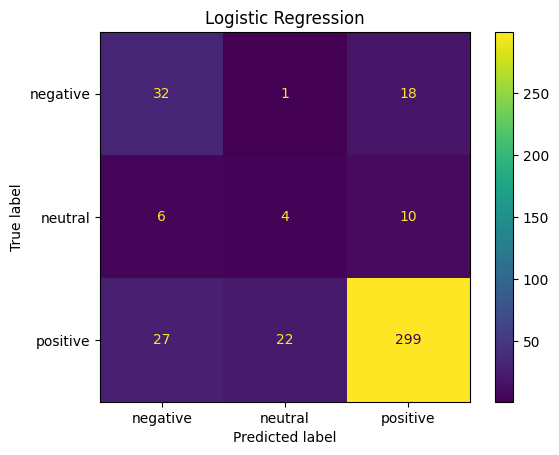

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred)

plt.title("Logistic Regression")
plt.show()


In [17]:
words = np.array(tfidf.get_feature_names_out())

for i, label in enumerate(logistic.classes_):
    top = logistic.coef_[i].argsort()[-15:]
    print(label)
    print(words[top])
    print()


negative
['boring' 'wants' 'snapchat' 'dark' 'dark mode' 'mode' 'lost' 'whatsapp'
 'status' 'anymore' 'data' 'iphone' 'fix' 'update' 'facebook']

neutral
['really' 'iphone5' 'update iphone5' 'just cat' 'bad good' 'funny app'
 'think' 'emoticons' 'waiting' 'ok' 'ethan' 'fine' 'funny' 'great love'
 'app awesome']

positive
['laugh' 'lol' 'really funny' 'awsome' 'fun' 'super' 'game' 'perfect'
 'cute' 'great' 'awesome' 'cool' 'app' 'best' 'love']



In [18]:
from transformers import pipeline

bert = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1)


Device set to use cpu


In [19]:
bert_data = english_reviews[
    english_reviews["sentiment"] != "neutral"]

bert_sample = bert_data.sample(
    min(2000, len(bert_data)),
    random_state=42).copy()

bert_results = bert(
    bert_sample["text"].tolist(),
    truncation=True,
    batch_size=8)


In [20]:
bert_sample["bert_sentiment"] = [
    x["label"].lower() for x in bert_results]

bert_sample["confidence"] = [
    x["score"] for x in bert_results]

bert_sample[
    ["text", "rating", "sentiment", "bert_sentiment", "confidence"]].head(10)


,text,rating,sentiment,bert_sentiment,confidence
9086,It is really fun because you get to act like y...,5,positive,positive,0.999793
9997,It's the best game ever,5,positive,positive,0.999862
4573,Whatsapp forever,5,positive,positive,0.986256
9677,It is so awesome to play,5,positive,positive,0.999879
9045,Tom is so funny every afternoon after high sch...,5,positive,positive,0.989364
9558,It is a really fun game to play,5,positive,positive,0.999866
9123,I think Tom is pretty cool in beudsert they ha...,5,positive,positive,0.631740
10097,Great app \nSoooooooo funny,5,positive,positive,0.999830
9706,A favourite app thats a keeper for me,5,positive,positive,0.999484
9433,I love Tom and Ben in Tom cat 2 It's so cool I...,5,positive,positive,0.999881


In [21]:
bert_accuracy = accuracy_score(
    bert_sample["sentiment"],
    bert_sample["bert_sentiment"])

bert_accuracy


0.8136272545090181

In [22]:
disagreements = bert_sample[
    bert_sample["sentiment"] != bert_sample["bert_sentiment"]]

disagreements[
    ["text", "rating", "sentiment", "bert_sentiment"]].head(10)


,text,rating,sentiment,bert_sentiment
5207,"Echt toll, super...",5,positive,negative
9324,When in bored I play with tom !,5,positive,negative
5927,sehr coool einfach super :)) \nman kann alles ...,5,positive,negative
4128,Whats app ist superrr!!💗,5,positive,negative
3631,Tolle App 😍,5,positive,negative
469,"This app is perfect no doubt, but please remov...",4,positive,negative
4078,Gute App.,4,positive,negative
9089,It's a hilarious game of talking Tom and Ben b...,5,positive,negative
851,"Only 4 people of group call is not enough,NO L...",5,positive,negative
530,Would be nice if there would be a seekbutton t...,5,positive,negative


In [23]:
bert_sample[
    (bert_sample["rating"] >= 4) &
    (bert_sample["bert_sentiment"] == "negative")
][["text", "rating"]].head(10)


,text,rating
5207,"Echt toll, super...",5
9324,When in bored I play with tom !,5
5927,sehr coool einfach super :)) \nman kann alles ...,5
4128,Whats app ist superrr!!💗,5
3631,Tolle App 😍,5
469,"This app is perfect no doubt, but please remov...",4
4078,Gute App.,4
9089,It's a hilarious game of talking Tom and Ben b...,5
851,"Only 4 people of group call is not enough,NO L...",5
530,Would be nice if there would be a seekbutton t...,5


In [31]:
negative = english_reviews[
    english_reviews["rating"] <= 2].copy()

custom_stopwords = [
    "whatsapp", "app", "facebook", "iphone",
    "tom", "game"]

stopwords = list(
    set(TfidfVectorizer(stop_words="english").get_stop_words())
    | set(custom_stopwords))

negative_tfidf = TfidfVectorizer(
    stop_words=stopwords,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8,
    max_features=2000)

matrix = negative_tfidf.fit_transform(negative["text"])

scores = np.asarray(matrix.mean(axis=0)).ravel()

phrases = pd.DataFrame({
    "phrase": negative_tfidf.get_feature_names_out(),
    "score": scores})

phrases = phrases.sort_values(
    "score",
    ascending=False).head(20)

phrases


,phrase,score
157,update,0.066601
101,new,0.033001
83,like,0.027917
79,just,0.026793
140,status,0.026279
152,time,0.023550
47,fix,0.023152
29,dark,0.022613
40,don,0.021761
103,new update,0.021687


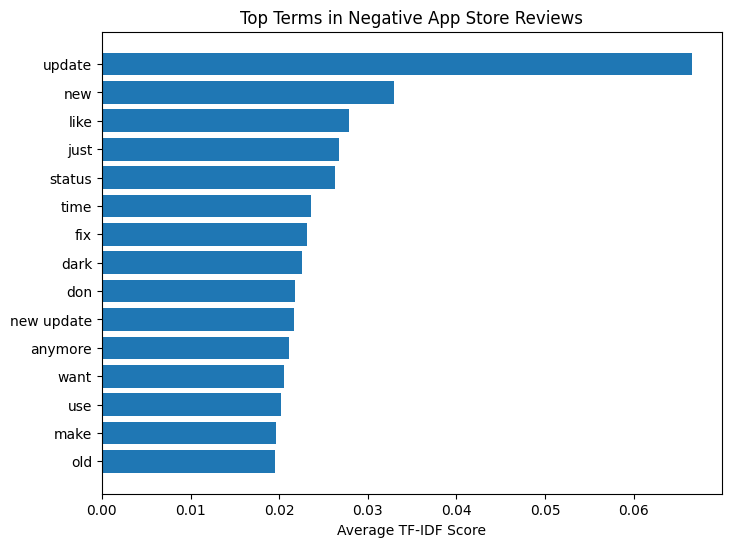

In [32]:
top = phrases.head(15).sort_values("score")

plt.figure(figsize=(8, 6))

plt.barh(
    top["phrase"],
    top["score"]
)

plt.title("Top Terms in Negative App Store Reviews")
plt.xlabel("Average TF-IDF Score")
plt.show()


In [29]:
app_sentiment = pd.crosstab(
    english_reviews["app_name"],
    english_reviews["sentiment"],
    normalize="index")

app_sentiment.head(10)


sentiment,negative,neutral,positive
app_name,,,
talking-tom-cat-2,0.052009,0.044129,0.903861
whatsapp-messenger,0.230583,0.049757,0.719660
